In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from netCDF4 import Dataset

import iris
import iris.coord_categorisation
import iris.plot as iplt
import iris.quickplot as qplt

import os
import logging

import numpy as np
import numpy.ma as ma

import pickle
from pathlib import Path

from IPython.display import clear_output
import gc

logger = logging.getLogger(__name__)

In [2]:
run plot_tools.ipynb

In [3]:
def average_dict(input):
    output=sum( np.array(input[clim] )[0][:] for clim in ESMS) / 3
    return(output)

In [4]:
def sum_carbon_pools(input):
    output=sum( np.array(input[var] ) [0][:] for var in VARIABLES )
    return(output)

get cVeg jules noluc
get cVeg jules agtoaff
plot cVeg jules agtoaff
get cVeg jules agtobio
plot cVeg jules agtobio
get cVeg clm noluc
get cVeg clm agtoaff
plot cVeg clm agtoaff
get cVeg clm agtobio
plot cVeg clm agtobio
get cVeg jsbach noluc
get cVeg jsbach agtoaff
plot cVeg jsbach agtoaff
get cVeg jsbach agtobio
plot cVeg jsbach agtobio
get cVeg orchidee noluc
get cVeg orchidee agtoaff
plot cVeg orchidee agtoaff
get cSoil clm noluc
get cSoil clm agtoaff
plot cSoil clm agtoaff
get cSoil clm agtobio
plot cSoil clm agtobio
get cSoil jsbach noluc
get cSoil jsbach agtoaff
plot cSoil jsbach agtoaff
get cSoil jsbach agtobio
plot cSoil jsbach agtobio
get cSoil orchidee noluc
get cSoil orchidee agtoaff
plot cSoil orchidee agtoaff
get cProduct clm noluc
get cProduct clm agtoaff
plot cProduct clm agtoaff
get cProduct clm agtobio
plot cProduct clm agtobio
get cProduct jsbach noluc
get cProduct jsbach agtoaff
plot cProduct jsbach agtoaff
get cProduct jsbach agtobio
plot cProduct jsbach agtobio
get

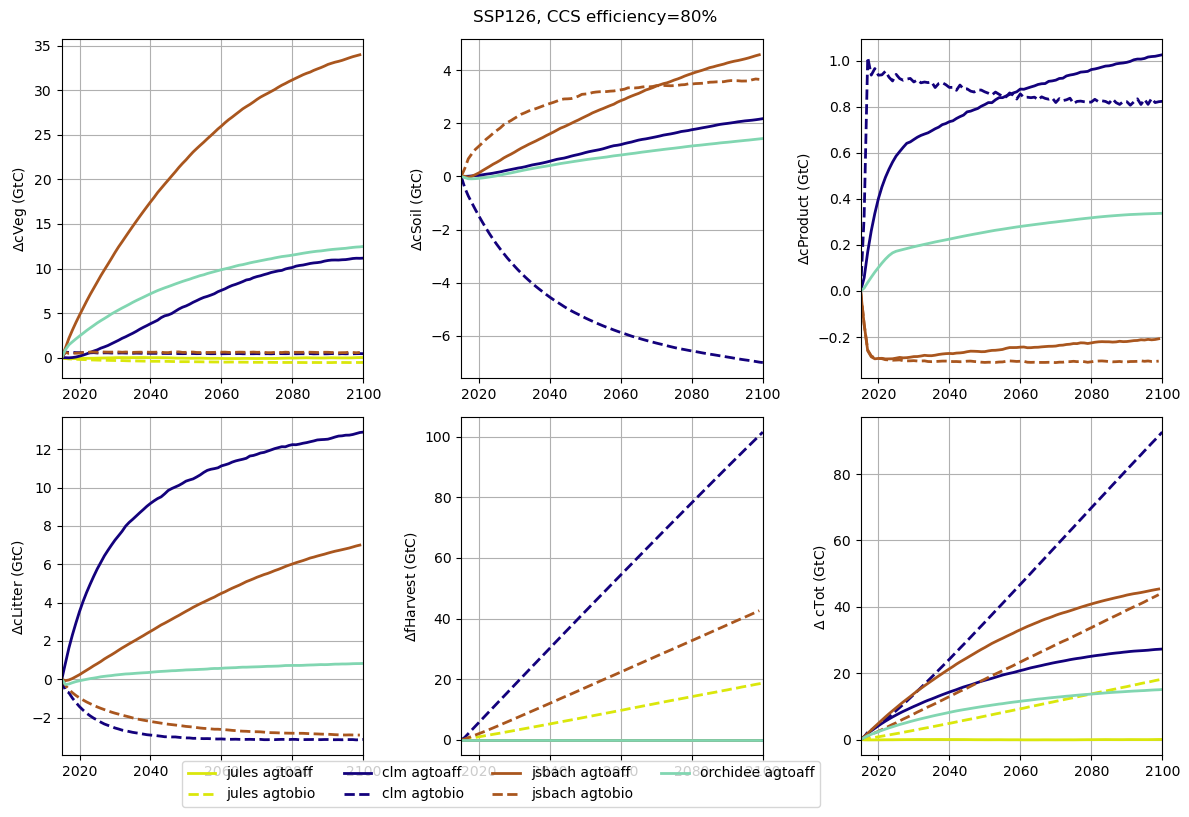

In [43]:
DECADES=['start','2030s','2050s','2090s']
MODELS=['jules','clm','jsbach','orchidee']
LANDUSES=['noluc','agtoaff','agtobio']
#SSPS=['ssp126']
SSPS=['ssp126','ssp370']
ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']
VARIABLES=['cVeg','cSoil','cProduct','cLitter','fHarvest','cTot']

years = np.arange(2015,2101)     
nyears = len(years)

capture_rate = 0.8
capture_pct = '80%'

#Set up plotting stuff
#Each land model needs a different color
fig,axes=plt.subplots(2,3, figsize=[12,8])
fig.suptitle('SSP126, CCS efficiency='+capture_pct,fontsize=12)

ix=0
iy=0

LU_SCENARIO_MEAN = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in LANDUSES} for lsm_mod in MODELS} 
                    for var in VARIABLES}

landuse_exists = {lsm_mod: {landuse: [True] for landuse in LANDUSES} for lsm_mod in MODELS}
#landuse_exists['jsbach']['agtonat'] = False
landuse_exists['orchidee']['agtobio'] = False
#landuse_exists['orchidee']['agtonat'] = False

variable_exists = {var: {landuse: {lsm_mod: [True] for lsm_mod in MODELS} 
                         for landuse in LANDUSES} for var in VARIABLES}
variable_exists['cSoil']['noluc']['jules'] = False
variable_exists['cSoil']['agtobio']['jules'] = False
#variable_exists['cSoil']['agtonat']['jules'] = False
variable_exists['cSoil']['agtoaff']['jules'] = False
variable_exists['cProduct']['noluc']['jules'] = False
#variable_exists['cProduct']['agtonat']['jules'] = False
variable_exists['cProduct']['agtoaff']['jules'] = False
variable_exists['cProduct']['agtobio']['jules'] = False
variable_exists['cLitter']['noluc']['jules'] = False
#variable_exists['cLitter']['agtonat']['jules'] = False
variable_exists['cLitter']['agtoaff']['jules'] = False
variable_exists['cLitter']['agtobio']['jules'] = False
#variable_exists['fHarvest']['agtonat']['jules'] = False
#variable_exists['fHarvest']['agtonat']['clm'] = False
#variable_exists['fHarvest']['agtonat']['jsbach'] = False
#variable_exists['fHarvest']['agtonat']['orchidee'] = False
#variable_exists['fHarvest']['agtoaff']['jules'] = False
#variable_exists['fHarvest']['agtoaff']['clm'] = False
#variable_exists['fHarvest']['agtoaff']['jsbach'] = False
#variable_exists['fHarvest']['agtoaff']['orchidee'] = False

test_mean={ssp: [] for ssp in SSPS}
colors = {model: [] for model in MODELS}

colors['jules'] = '#DAE70B'
colors['clm'] = '#13017C'
colors['jsbach'] = '#A9561E'
colors['orchidee'] = '#81D6B1'
#https://matplotlib.org/stable/users/explain/colors/colors.html

linestyles = {landuse: [] for landuse in LANDUSES}
linestyles['agtoaff'] = '-'
#linestyles['agtonat'] = '-'

linestyles['agtobio'] = '--'

for var in VARIABLES[:-1]:

    # set axes
    ax=axes[iy,ix]
    ax.set_ylabel(r'$\Delta$' +var+' (GtC) ',fontsize=10)
    ax.set_xlim([2015,2100])
    ax.grid(True) 
    
    for model in MODELS:
        #First get no land use change (noluc)
        for landuse in LANDUSES:
            if landuse_exists[model][landuse]:
                if variable_exists[var][landuse][model]:
                    if model=='jules' and landuse=='noluc':
                        luname='nolucbio'
                    else:
                        luname=landuse

                    if var=='fHarvest':
                        if model=='jules':
                            varname='fBioHarvestpft'
                            units='tC/ha' #originally kgC/m2/s
                        elif model=='jsbach':
                            varname='cHbpharv'
                            units='tC/ha'  #originally kgC/m2
                        else:
                            varname=var
                            units='tC/ha'  #originally kgC/m2/s (CLM)
                        cdata,cdata_tr,cdata_te = retrieve_data_generic(varname,units,luname,model)

                        for ssp in SSPS:
                            totharvest=average_dict(cdata[ssp]) * 0.10 #Convert from tC/ha to PgC                             
                            if landuse!='agtobio':
                                #Assume rapid return of harvests to the atmosphere:
                                LU_SCENARIO_MEAN[var][model][landuse][ssp]=totharvest*0.01
                            else:                            
                                if model=='jsbach':
                                    LU_SCENARIO_MEAN[var][model][landuse][ssp]=totharvest*capture_rate    
                                else:
                                    LU_SCENARIO_MEAN[var][model][landuse][ssp]=np.cumsum(totharvest)*capture_rate
                                del(totharvest)

                    elif var=='cLitter' and model=='clm':
                        cdata,cdata_tr,cdata_te = retrieve_data_generic(var,'PgC',luname,model)
                        cwd,cwd_tr,cwd_te = retrieve_data_generic('cCwd','PgC',luname,model)
                        print('get',var,model,landuse)
                        for ssp in SSPS:
                            LU_SCENARIO_MEAN[var][model][landuse][ssp]=average_dict(cwd[ssp]) + average_dict(cdata[ssp])
        
                    else:
                        cdata,cdata_tr,cdata_te = retrieve_data_generic(var,'PgC',luname,model)
                        print('get',var,model,landuse)

                        for ssp in SSPS:
                            LU_SCENARIO_MEAN[var][model][landuse][ssp]=average_dict(cdata[ssp])
                    
                    for ssp in SSPS:
                        if var=='cVeg':
                            LU_SCENARIO_MEAN['cTot'][model][landuse][ssp] = LU_SCENARIO_MEAN[var][model][landuse][ssp]
                        else:              
                            LU_SCENARIO_MEAN['cTot'][model][landuse][ssp] += LU_SCENARIO_MEAN[var][model][landuse][ssp]
                    
                    
                    
                    #Now that we have the data, plot it.
                    if landuse != 'noluc':
                        print('plot',var,model,landuse)
                        ssp='ssp126'
                        if model=='jsbach':
                            endyear=nyears-1
                        else:
                            endyear=nyears
                        plot_luc=((LU_SCENARIO_MEAN[var][model][landuse][ssp])- \
                                  (LU_SCENARIO_MEAN[var][model][landuse][ssp])[0])
                        plot_noluc=((LU_SCENARIO_MEAN[var][model]['noluc'][ssp])- \
                                  (LU_SCENARIO_MEAN[var][model]['noluc'][ssp])[0])
                            
                        plabel=model+' '+landuse
                
                        ax.plot(years[:endyear], plot_luc - plot_noluc, label=plabel,
                                c=colors[model],ls=linestyles[landuse],lw=2)                  
                        del(plot_luc)
    
    ix+=1
    if ix==3:
        ix=0
        iy+=1


landuse_CDR = {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in LANDUSES} for lsm_mod in MODELS} 


#Plot the sum
ax=axes[iy,ix]
ax.set_ylabel(r'$\Delta$ cTot (GtC) ',fontsize=10)
ax.set_xlim([2015,2100])
ax.grid(True) 
for model in MODELS:
    for landuse in LANDUSES[1:]:
        if landuse_exists[model][landuse]:    
            ssp='ssp126'
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears
        
            plabel=model+' '+landuse

            plot_noluc=(LU_SCENARIO_MEAN['cTot'][model]['noluc'][ssp])- \
                        (LU_SCENARIO_MEAN['cTot'][model]['noluc'][ssp])[0]
            plot_luc = (LU_SCENARIO_MEAN['cTot'][model][landuse][ssp])- \
                        (LU_SCENARIO_MEAN['cTot'][model][landuse][ssp])[0]

            landuse_CDR[model][landuse][ssp] = plot_luc - plot_noluc
            
            ax.plot(years[:endyear], plot_luc - plot_noluc , label=plabel,
                    c=colors[model],ls=linestyles[landuse],lw=2)
fig.tight_layout()

handles,labels = ax.get_legend_handles_labels()
fig.legend(handles,labels,ncol=4,loc='upper left',bbox_to_anchor=(0.15, 0.05),fontsize=10)

plt.savefig('/bdd/ESM2025/WP10/plots/AR_BECCS_CDR'+capture_pct+'.png', format="png")

    

plot cTOT jules agtoaff
plot cTOT jules agtobio
plot cTOT clm agtoaff
plot cTOT clm agtobio
plot cTOT jsbach agtoaff
plot cTOT jsbach agtobio
plot cTOT orchidee agtoaff


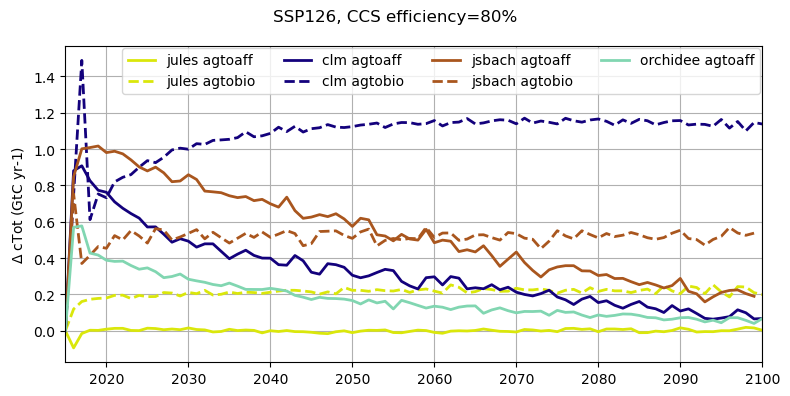

In [44]:
fig2,ax2=plt.subplots(1,1, figsize=[8,4])
fig2.suptitle('SSP126, CCS efficiency='+capture_pct,fontsize=12)

ax2.set_ylabel(r'$\Delta$ cTot (GtC yr-1)',fontsize=10)
ax2.set_xlim([2015,2100])
ax2.grid(True) 

for model in MODELS:
    for landuse in LANDUSES[1:]:
        if landuse_exists[model][landuse]:    
            print('plot cTOT',model,landuse)
            ssp='ssp126'
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears
        
            plabel=model+' '+landuse
            
            plot_luc2 = np.full_like(landuse_CDR[model][landuse][ssp], 0)

            for yr in range(1,endyear):
                plot_luc2[yr]=landuse_CDR[model][landuse][ssp][yr] - landuse_CDR[model][landuse][ssp][yr-1]

            ax2.plot(years[:endyear], plot_luc2, label=plabel,
                    c=colors[model],ls=linestyles[landuse],lw=2)

handles,labels = ax.get_legend_handles_labels()
fig2.legend(handles,labels,ncol=4,loc='upper left',bbox_to_anchor=(0.15, 0.90),fontsize=10)
fig2.tight_layout()

plt.savefig('/bdd/ESM2025/WP10/plots/AR_BECCS_CDR_per_year_'+capture_pct+'.png', format="png")